Create Model 1 using Tensorflow

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import PIL

from tensorflow import keras
from tensorflow.keras import layers

datasetPath = kagglehub.dataset_download("ongshujian/real-and-fake-pokemon-cards")

def build_tensor_deep_model(hp):
    base_filters = hp.Choice("base_filter", [16, 32]) # for feature extraction
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions = hp.Choice("activation", ["relu", "sigmoid", "tanh", "elu"]) # activation function.
    model = keras.models.Sequential([
        layers.Conv2D(base_filters, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 2, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 4, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activeFunctions),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer='adam', loss=keras.losses.BinaryCrossentropy(), metrics=[
        keras.metrics.Recall(),
        keras.metrics.AUC() #because our dataset is imbalanced
    ])
    return model



Process the data and produce the class distribution plots for training set.

Note: you may need to restart the kernel to use updated packages.


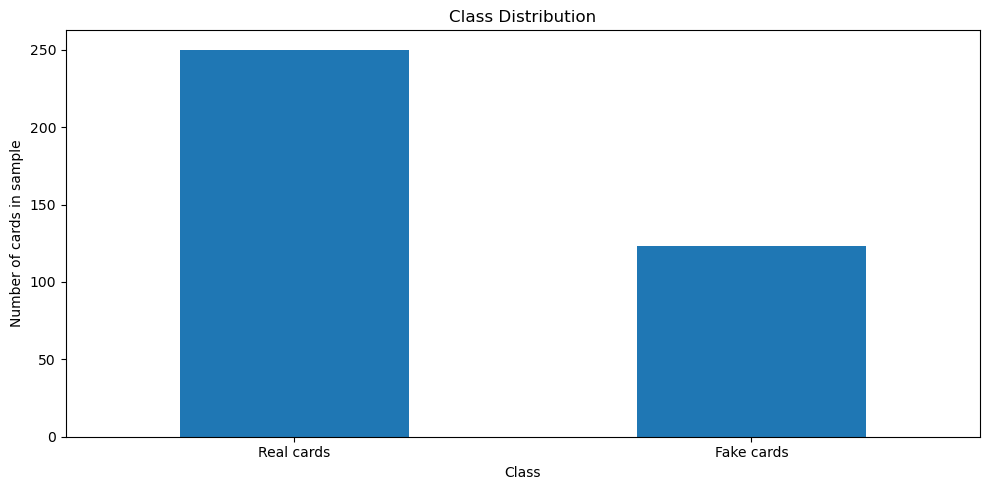

In [2]:
#install keras tuner so we can tune hypermodels in Tensorflow
%pip install -q -U keras-tuner

import os
#we'll use this tool for training validation split for relative ease of use
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import keras_tuner as kt

df = pd.read_csv(f"{datasetPath}/train_labels.csv") 

#class distribution plot for training set

plt.figure(figsize=(10,5))
df["label"].map({0: "Fake cards", 1: "Real cards"}).value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of cards in sample")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

We're going to do some EDA here. Going to validate and check if images are corrupted

   id  label                                               path
0   1      0  C:\Users\Tyler Vo\.cache\kagglehub\datasets\on...
1   2      0  C:\Users\Tyler Vo\.cache\kagglehub\datasets\on...
2   3      0  C:\Users\Tyler Vo\.cache\kagglehub\datasets\on...
3   4      0  C:\Users\Tyler Vo\.cache\kagglehub\datasets\on...
4   5      0  C:\Users\Tyler Vo\.cache\kagglehub\datasets\on...
There are 0 images missing in the dataset
Empty DataFrame
Columns: [id, label, path]
Index: []


<Figure size 640x480 with 0 Axes>

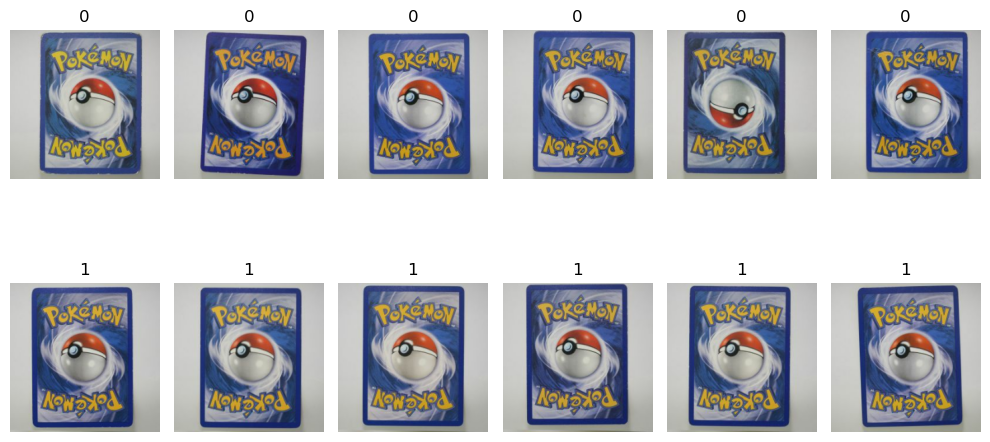

In [3]:
# We already figured out class distribution and class names.
#reconstruct the paths
imageCheck = df

imageCheck["path"] = imageCheck["id"].apply(
    lambda x: os.path.join(datasetPath, "train", f"{x}.JPG")
)

print(imageCheck.head())

missingImages = df[~df["path"].apply(os.path.exists)]
print(f"There are {len(missingImages)} images missing in the dataset")
print(missingImages.head())


def loadImagesToCheck(path):
    imageSize = (224, 224)
    imageLoaded = tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(path), channels=3), imageSize)
    return tf.cast(imageLoaded, tf.uint8)

sampleImageCheck = df.groupby("label").sample(6, random_state=42)

plt.figure()
plt.figure(figsize=(10,6))

for i, row in enumerate(sampleImageCheck.itertuples()):
    image = loadImagesToCheck(row.path)
    plt.subplot(2, 6, i + 1)
    plt.imshow(image.numpy())
    plt.title(f"{row.label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Now we need to check if the images are consistent, uncorrupted, and had mean image per class calculated

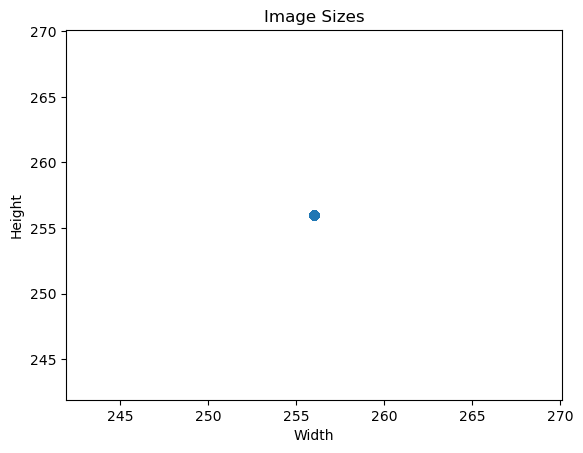

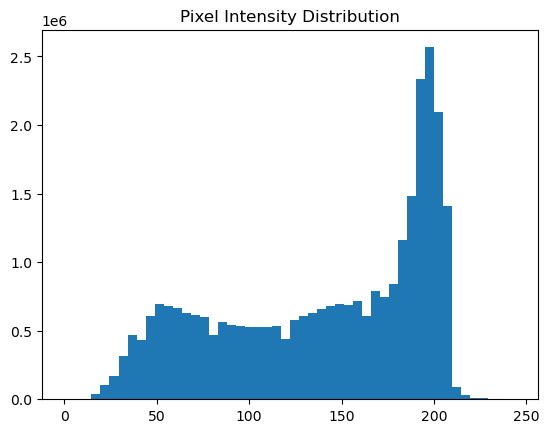

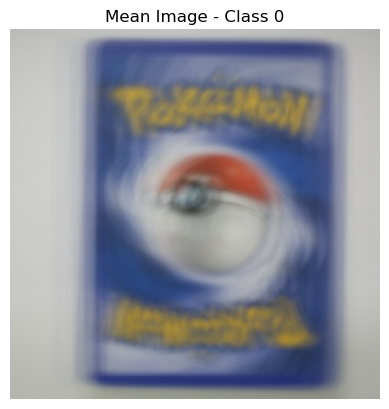

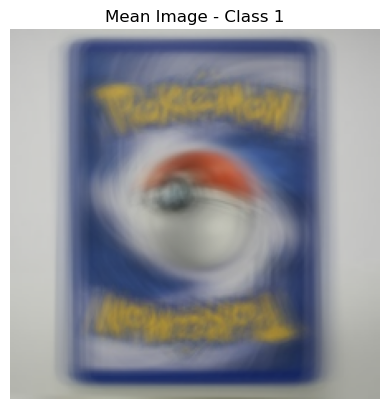

In [4]:
# check image size distributions
sizes = []
for path in imageCheck["path"]:
    try:
        with PIL.Image.open(path) as img:
            sizes.append(img.size)
    except: pass

widths, heights = zip(*sizes)

plt.scatter(widths, heights, alpha=0.3)
plt.title("Image Sizes")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

#check pixel intensity
def pixelDist(paths, n=200):
    pixels = []

    for p in paths[:n]:
        img = loadImagesToCheck(p).numpy()
        pixels.append(img.flatten())
    pixels = np.concatenate(pixels)

    plt.hist(pixels, bins=50)
    plt.title("Pixel Intensity Distribution")
    plt.show()

pixelDist(imageCheck["path"].values)

def meanImage(label):
    subset = imageCheck[imageCheck["label"] == label].sample(50, random_state=42)

    imgs = [loadImagesToCheck(p).numpy() for p in subset["path"]]

    imagesMean = np.mean(imgs, axis=0)

    plt.imshow(imagesMean.astype("uint8"))
    plt.title(f"Mean Image - Class {label}")
    plt.axis("off")
    plt.show()

#check for both labels
meanImage(0)
meanImage(1)

# We can assume test data is of same make.
# Preprocessing should not be necessary from the visual glance. 

Split the training set into training and validation sets. Train and tune hyperparameters.

Trial 16 Complete [00h 01m 43s]
val_auc: 0.5

Best val_auc So Far: 1.0
Total elapsed time: 00h 19m 03s
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - auc_2: 0.4927 - loss: 1.0559 - recall_3: 0.3878 - val_auc_2: 0.8812 - val_loss: 0.5855 - val_recall_3: 0.0000e+00
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - auc_2: 0.8139 - loss: 0.5195 - recall_3: 0.3367 - val_auc_2: 0.8836 - val_loss: 0.4819 - val_recall_3: 0.4000
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - auc_2: 0.8562 - loss: 0.4493 - recall_3: 0.6633 - val_auc_2: 0.9096 - val_loss: 0.4405 - val_recall_3: 0.4400
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - auc_2: 0.9078 - loss: 0.3733 - recall_3: 0.6531 - val_auc_2: 0.9688 - val_loss: 0.2892 - val_recall_3: 0.7200
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - auc_2: 0.9435 - loss: 0.3021 - recall_3: 0.7143 - val_auc_2: 0.9768 - val_loss: 0.2153 - val_recall_3: 0.8000
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - auc_2: 0.9923 - los

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,704,933 (37.02 MB)

 Trainable params: 3,234,977 (12.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,469,956 (24.68 MB)

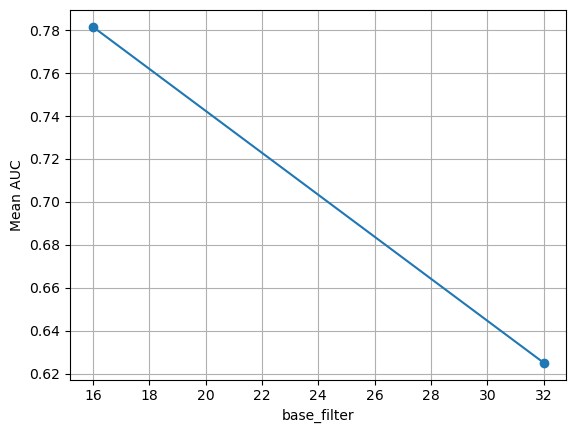

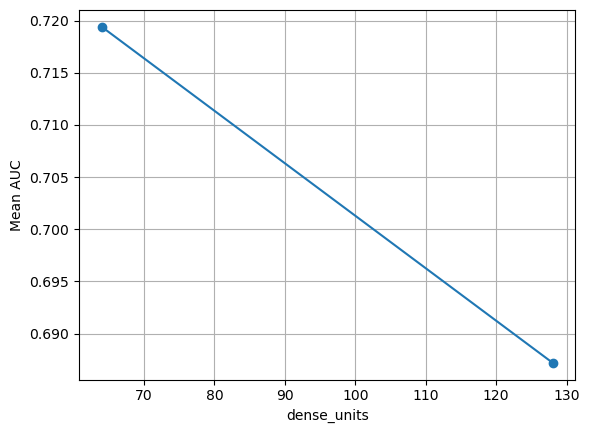

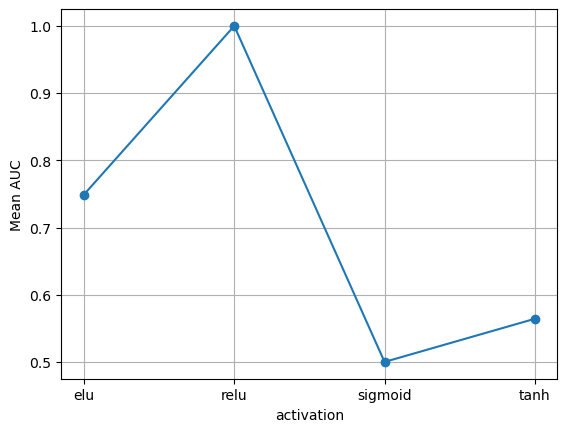

In [5]:
#shuffle dataset because the original dataset is ordered. We want to keep 
photoID_training, photoID_valid, classify_training, classify_valid = train_test_split(
    df["id"], df["label"],
    test_size= .2,
    stratify = df["label"],
    random_state=42
)

def processThroughImages(imagesCollection, labels, stage):
    imagesArray = []
    labelToReturn= []
    # Images 1 - 298 in our dataset will be our training data. Rest will be testing
    for imageID, label in zip(imagesCollection, labels):
        imageToProcessFilePath = os.path.join(datasetPath, stage, f"{imageID}.JPG")
        
        if not os.path.exists(imageToProcessFilePath):
            print(f"Missing: {imageToProcessFilePath}")
            continue

        imageToProcess = keras.utils.img_to_array(keras.utils.load_img(imageToProcessFilePath, target_size=[224,224]))
        
        imagesArray.append(imageToProcess)
        labelToReturn.append(label)
    
    
    return np.array(imagesArray), np.array(labelToReturn)

trainingImagesArray, trainingClassifyArray = processThroughImages(photoID_training, classify_training, "train")
validationImagesArray, validationClassifyArray = processThroughImages(photoID_valid, classify_valid, "train")

#normalize for model's ease
trainingImagesArray /= 255.0
validationImagesArray /= 255.0

#invert classification arrays to prioritize going after fake cards. Remember to do the same for the test function.
trainingClassifyArray = 1 - trainingClassifyArray
validationClassifyArray = 1 - validationClassifyArray

# hypertune parameters with model 1 and see what we can do
model1Tuner = kt.GridSearch(
    build_tensor_deep_model,
    objective="val_auc",
    max_trials=None,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifierDeepModel"
)

model1Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

# display our results of our tuning here. 
def showHyperPlot(param: str, results, groupBy="mean_test_score"):
  toPlot = results.groupby(param)[groupBy].mean()
  plt.figure()
  plt.plot(toPlot.index, toPlot.values, marker="o")
  plt.xlabel(param)
  plt.ylabel("Mean AUC")
  plt.grid(True)
  plt.show()




# rebuild with best hyperparameters and get our final tuned model
model1 = model1Tuner.hypermodel.build(model1Tuner.get_best_hyperparameters(1)[0])

model1.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model1Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model1Tuner.oracle.trials.values() if t.score is not None
])
print(model1Results.columns)
print(model1Results.head())


model1.summary()
showHyperPlot("base_filter", model1Results, "score")
showHyperPlot("dense_units", model1Results, "score")
showHyperPlot("activation", model1Results, "score")

Let's try creation a second model and see which one is more accurate. We're going to build a Tensorflow shallow learning model (even if it is not recommended for image processing and classification) and see if it could ever beat it.

In [ ]:
#Let's tune hyperparameters
def build_tensor_shallow_model(hp):
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions = hp.Choice("activation", ["relu", "sigmoid", "tanh", "elu"])
    model = keras.models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activeFunctions),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer='adam', loss=keras.losses.BinaryCrossentropy(), metrics=[
        keras.metrics.Recall(),
        keras.metrics.AUC() #because our dataset is imbalanced
    ])
    return model

model2Tuner = kt.RandomSearch(
    build_tensor_shallow_model,
    objective="val_auc",
    max_trials=50,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifierShallowModel"
)

model2Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model2Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model2Tuner.oracle.trials.values() if t.score is not None
])

model2 = model2Tuner.hypermodel.build(model2Tuner.get_best_hyperparameters(1)[0])

model2.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model2.summary()
showHyperPlot("dense_units", model2Results, "score")
showHyperPlot("activation", model2Results, "score")

Test it on the test data we have set, then compare the two models. Pick the best one from here and export as a backend api

In [ ]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score, classification_report

#prepare test set
testDF = pd.read_csv(f"{datasetPath}/test_labels.csv").sample(frac=1, random_state=42).reset_index(drop=True)
plt.figure(figsize=(10,5))
testDF["label"].map({0: "Fake cards", 1: "Real cards"}).value_counts().plot(kind="bar")
plt.title("Class Distribution For Test Cases.")
plt.xlabel("Class")
plt.ylabel("Number of cards in sample")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


testImagesArray, testClassifyArray = processThroughImages(testDF["id"], testDF["label"], "test")
testClassifyArray = 1 - testClassifyArray
testClassifyArray = testClassifyArray.astype(int).reshape(-1)

# test model 1
testCheckProbs1 = model1.predict(testImagesArray).reshape(-1)
testCheck1 = (testCheckProbs1 > 0.5).astype(int)

print(f"Model 1 f1-score: {f1_score(testClassifyArray, testCheck1)}")
print(f"Model 1 recall-score: {recall_score(testClassifyArray, testCheck1)}")
print(f"Model 1 auc-score: {roc_auc_score(testClassifyArray, testCheckProbs1)}")
print(classification_report(testClassifyArray, testCheck1, target_names=["Real Cards","Fake Cards"]))

# test model 2
testCheckProbs2 = model2.predict(testImagesArray).reshape(-1)
testCheck2 = (testCheckProbs2 > 0.5).astype(int)

print(f"Model 2 f1-score: {f1_score(testClassifyArray, testCheck2)}")
print(f"Model 2 recall-score: {recall_score(testClassifyArray, testCheck2)}")
print(f"Model 2 auc-score: {roc_auc_score(testClassifyArray, testCheckProbs2)}")
print(classification_report(testClassifyArray, testCheck2, target_names=["Real Cards","Fake Cards"]))





Use this information to export and download the winning model. Because model 1 won in accuracy, we can save it here.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model1.save('/content/drive/MyDrive/fakeCardCNN.keras')